# Lab 05 — Image Segmentation Tasks

This notebook covers **all ten tasks** in the Lab 05 task sheet using basic Python, OpenCV, NumPy and Matplotlib. It follows the Lab 05 manual's examples for thresholding, HSV masks, Canny, region growing, watershed and K-Means.

Run the setup cell first, place the images in an `images` folder beside this notebook, then run the tasks in order. All figures are saved to a `results` folder. Image files are inputs, not supplied inside the lab PDFs. The screenshot names `sudoku.png`, `smarties.png`, a touching-coins image, a brain MRI, and optionally `dog.jpeg`; Task 10 reuses `smarties.png`.

Useful source pages: [OpenCV Sudoku image](https://github.com/opencv/opencv/blob/master/samples/data/sudoku.png), [OpenCV watershed tutorial and coins image](https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html), and [OpenCV thresholding tutorial with Smarties](https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html). For the brain MRI, save the image from the linked article in your screenshot as `brain_mri.png`. Check that each downloaded picture is the intended one; some sites give downloaded files different names.

If needed, install packages with `pip install opencv-python numpy matplotlib`. No pretrained model or segmentation library is used.

In [13]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = Path('images')
RESULT_DIR = Path('results')
RESULT_DIR.mkdir(exist_ok=True)

# Change only these names if your downloaded files have different names.
SUDOKU = IMAGE_DIR / 'sudoku.png'
SMARTIES = IMAGE_DIR / 'smarties.png'
COINS = IMAGE_DIR / 'coins.jpg'
BRAIN = IMAGE_DIR / 'brain_mri.png'

def load_image(path, gray=False):
    mode = cv2.IMREAD_GRAYSCALE if gray else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), mode)
    if image is None:
        raise FileNotFoundError(f'Image not found: {path}. Put it in the images folder or change its path above.')
    return image

def rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_and_save(name, images, titles, columns=4):
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap='gray' if image.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes[len(images):]:
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(RESULT_DIR / name, dpi=150, bbox_inches='tight')
    plt.show()

print('Image folder:', IMAGE_DIR.resolve())
print('Result folder:', RESULT_DIR.resolve())

Image folder: /content/images
Result folder: /content/results


### Get the sample images

Run the next cell if the images are not already in `images/`. It downloads the public OpenCV Sudoku, Smarties and touching-coins examples linked from the source pages above. The brain MRI from your classroom screenshot is a separate article image: save it manually as `images/brain_mri.png`. If the download cell cannot reach the web, use the links above and save the files yourself. The code below never overwrites an existing image.

In [14]:
from urllib.request import urlretrieve

IMAGE_DIR.mkdir(exist_ok=True)
image_urls = {
    SUDOKU: 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/sudoku.png',
    SMARTIES: 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/smarties.png',
    COINS: 'https://docs.opencv.org/4.13.0/water_coins.jpg',
}
for target, url in image_urls.items():
    if target.exists():
        print('Already available:', target)
    else:
        try:
            urlretrieve(url, target)
            print('Downloaded:', target)
        except Exception as error:
            print('Could not download', target, '— use the source link manually.', error)
print('Brain MRI:', 'available' if BRAIN.exists() else 'save your MRI image as images/brain_mri.png')

Already available: images/sudoku.png
Already available: images/smarties.png
Already available: images/coins.jpg
Brain MRI: available


## Task 1 — Document under uneven lighting

Compare three global thresholds with one adaptive result on the Sudoku/document image. White pixels are paper; dark pixels are text. The brighter and darker sides may require different thresholds.

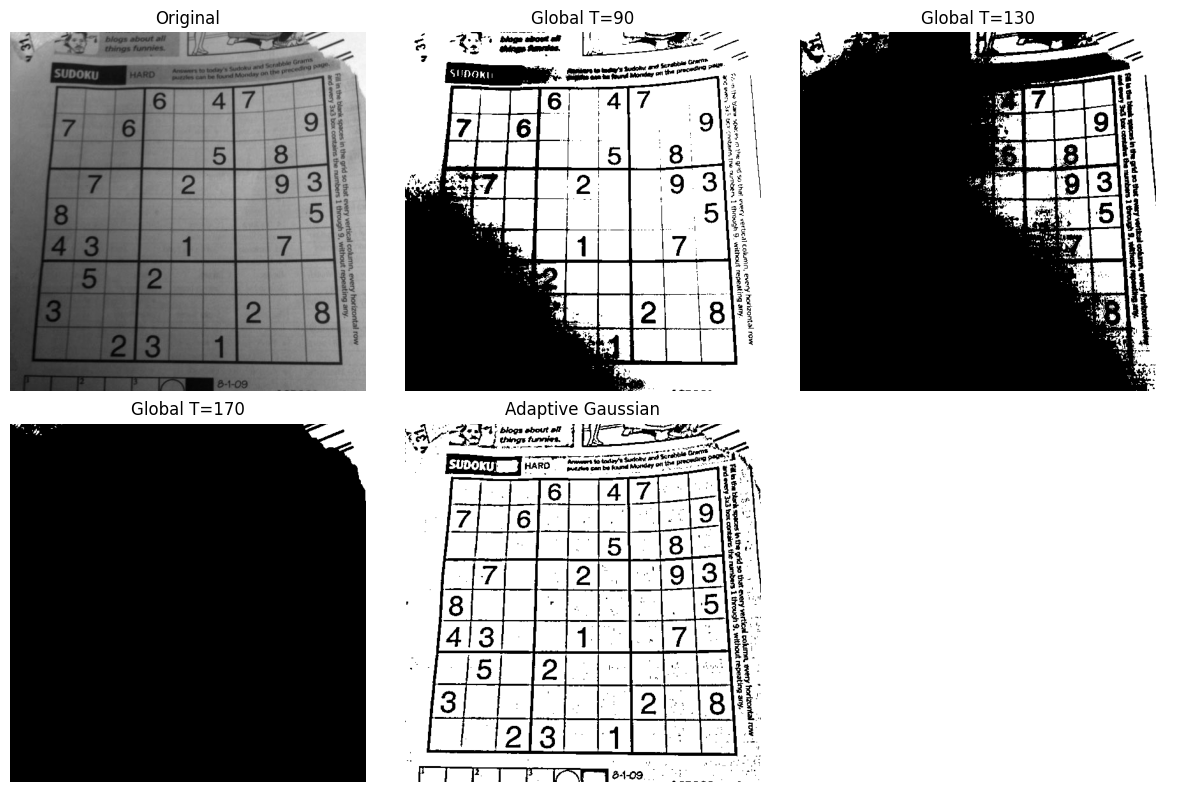

Selected parameters: global thresholds [90, 130, 170] ; adaptive blockSize=21, C=5
Inspect dark and bright sides: one global value can lose text on one side, while local thresholding adjusts by area.


In [15]:
document = load_image(SUDOKU, gray=True)
thresholds = [90, 130, 170]
global_masks = [cv2.threshold(document, t, 255, cv2.THRESH_BINARY)[1] for t in thresholds]
adaptive_1 = cv2.adaptiveThreshold(document, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 21, 5)
show_and_save('task01_document.png',
              [document, *global_masks, adaptive_1],
              ['Original', *[f'Global T={t}' for t in thresholds], 'Adaptive Gaussian'], 3)
print('Selected parameters: global thresholds', thresholds, '; adaptive blockSize=21, C=5')
print('Inspect dark and bright sides: one global value can lose text on one side, while local thresholding adjusts by area.')

## Task 2 — Choose an adaptive threshold strategy

Test three odd `blockSize` values and three `C` values for **both** mean and Gaussian adaptive thresholding. A small window follows tiny variations and can create noise; a very large one may miss local lighting changes. Increasing `C` subtracts more from the local threshold, usually making more pixels white with `THRESH_BINARY`.

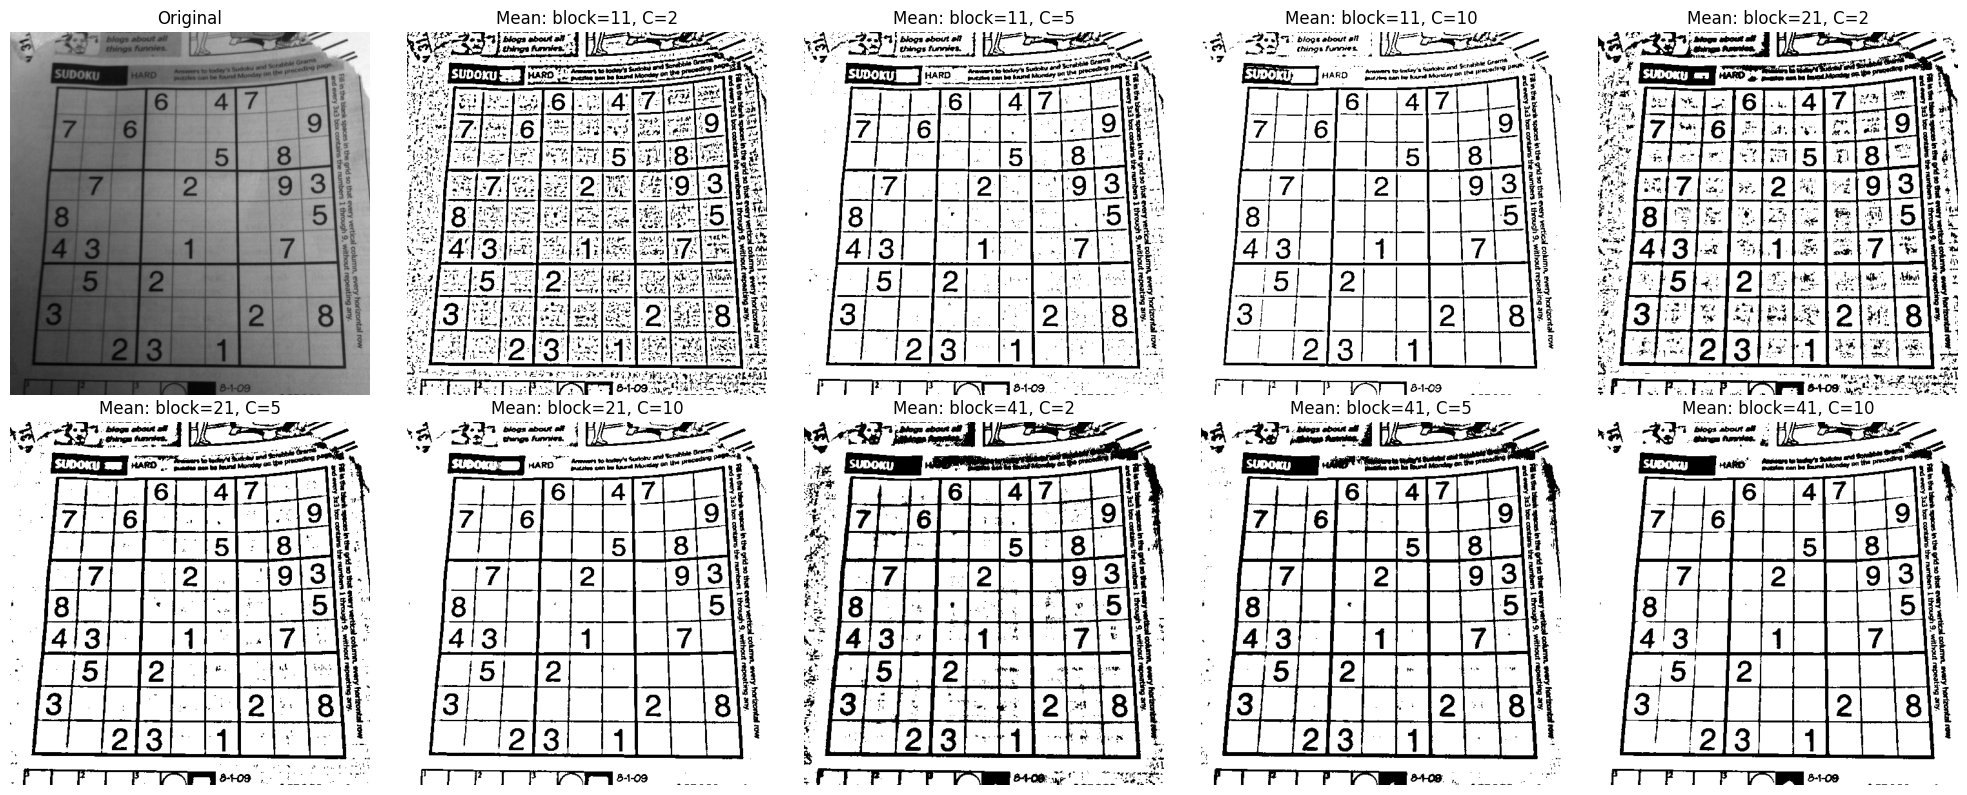

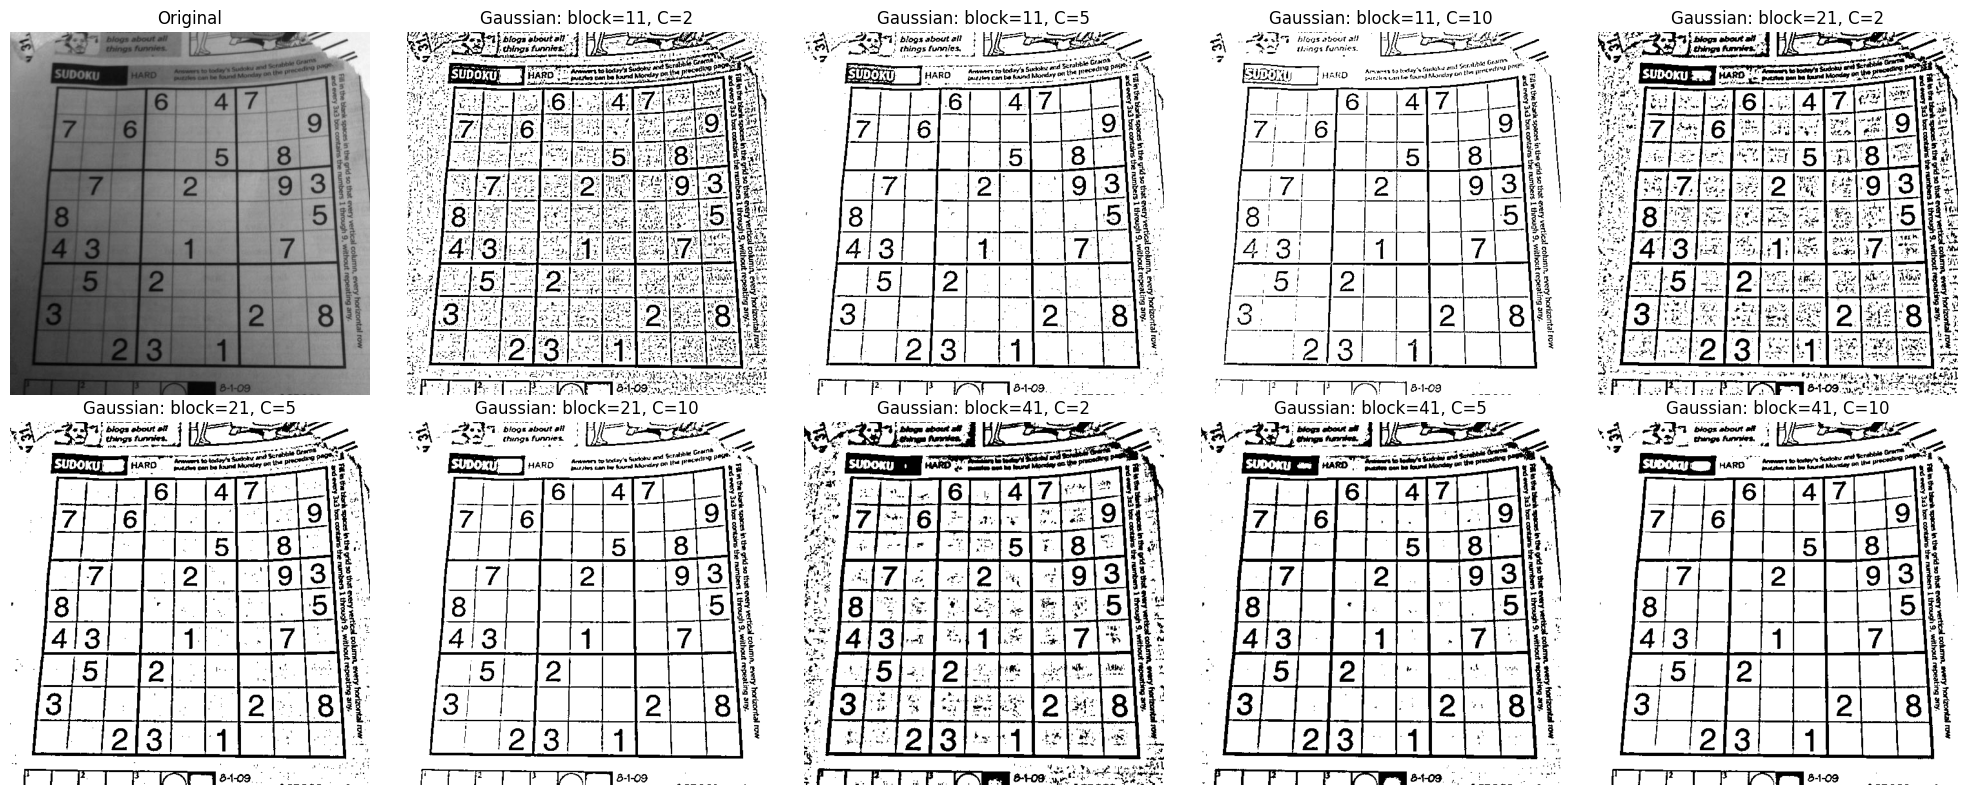

Compare broken letters and speckles. A good choice keeps text readable without adding excessive noise.


In [16]:
block_sizes = [11, 21, 41]  # Must be odd and greater than 1.
c_values = [2, 5, 10]
methods = [('Mean', cv2.ADAPTIVE_THRESH_MEAN_C),
           ('Gaussian', cv2.ADAPTIVE_THRESH_GAUSSIAN_C)]
for method_name, method in methods:
    pictures, labels = [document], ['Original']
    for block in block_sizes:
        for c in c_values:
            mask = cv2.adaptiveThreshold(document, 255, method, cv2.THRESH_BINARY, block, c)
            pictures.append(mask)
            labels.append(f'{method_name}: block={block}, C={c}')
    show_and_save(f'task02_{method_name.lower()}.png', pictures, labels, 5)
print('Compare broken letters and speckles. A good choice keeps text readable without adding excessive noise.')

## Task 3 — Otsu thresholding

Otsu chooses the threshold from the grayscale histogram. The second run changes contrast with CLAHE, then lets Otsu choose again. We record both thresholds instead of setting one manually.

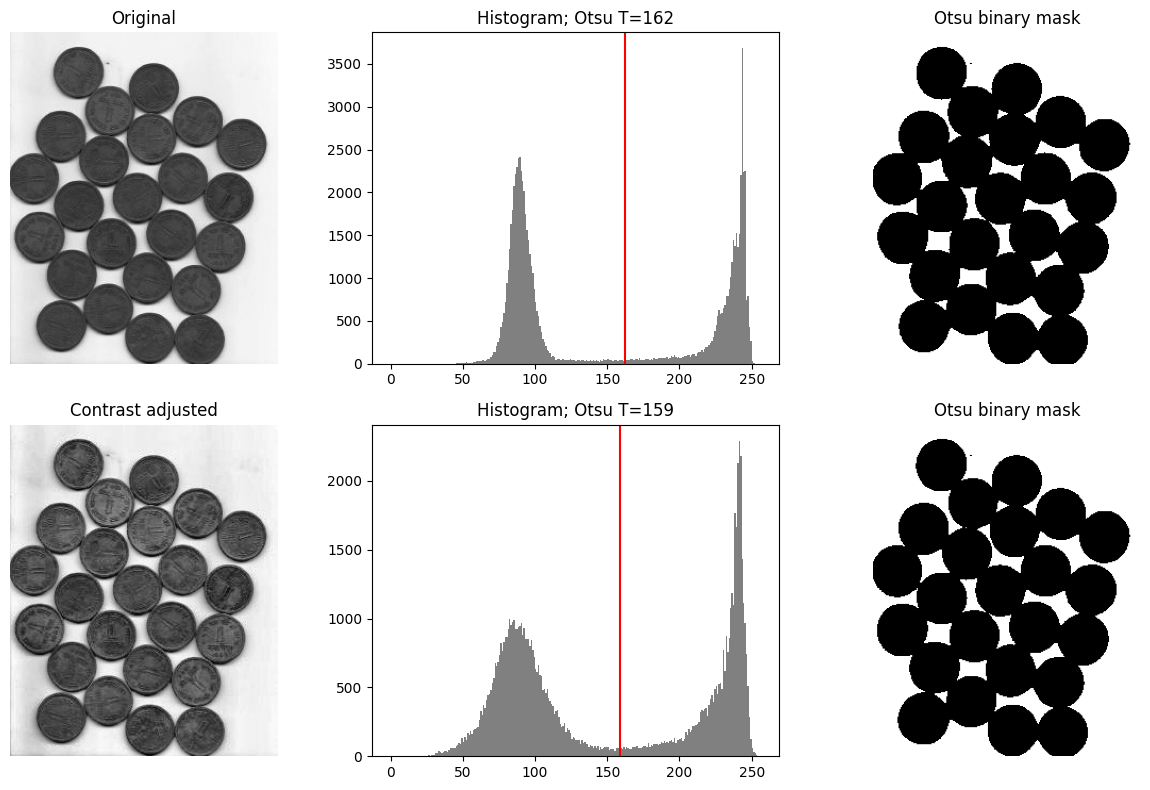

Otsu thresholds: original=162, contrast adjusted=159
Otsu is useful when foreground and background form reasonably distinct intensity groups.


In [17]:
coins_color = load_image(COINS)
coins_gray = cv2.cvtColor(coins_color, cv2.COLOR_BGR2GRAY)
otsu_t, otsu_mask = cv2.threshold(coins_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contrast = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(coins_gray)
contrast_t, contrast_mask = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (image, mask, value, label) in enumerate([
    (coins_gray, otsu_mask, otsu_t, 'Original'),
    (contrast, contrast_mask, contrast_t, 'Contrast adjusted')]):
    axes[row, 0].imshow(image, cmap='gray'); axes[row, 0].set_title(label)
    axes[row, 1].hist(image.ravel(), bins=256, range=(0, 256), color='gray')
    axes[row, 1].axvline(value, color='red'); axes[row, 1].set_title(f'Histogram; Otsu T={value:.0f}')
    axes[row, 2].imshow(mask, cmap='gray'); axes[row, 2].set_title('Otsu binary mask')
    axes[row, 0].axis('off'); axes[row, 2].axis('off')
fig.tight_layout(); fig.savefig(RESULT_DIR / 'task03_otsu.png', dpi=150); plt.show()
print(f'Otsu thresholds: original={otsu_t:.0f}, contrast adjusted={contrast_t:.0f}')
print('Otsu is useful when foreground and background form reasonably distinct intensity groups.')

## Task 4 — Sort objects by color

Convert Smarties to HSV, select blue objects with lower and upper bounds, then show a deliberately narrow mask and a fuller one. Hue ranges in OpenCV are 0–179, while saturation and value are 0–255. Change the bounds if your chosen image has a different target color.

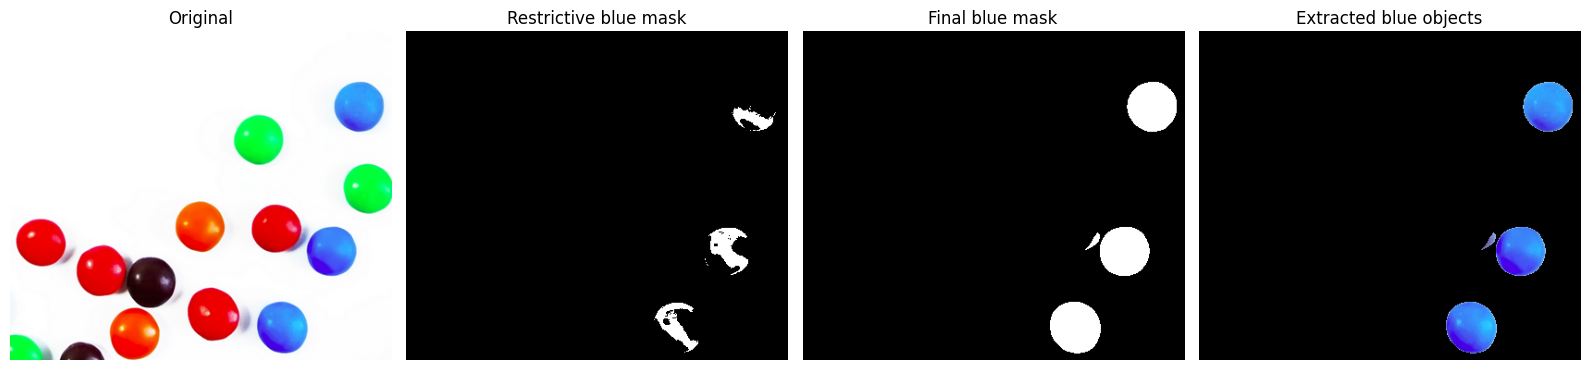

Restrictive bounds: [108 170 130] [118 255 255]
Final bounds: [90 70 40] [135 255 255]
The narrow range can miss shaded or less saturated parts of a blue object.


In [18]:
smarties = load_image(SMARTIES)
hsv = cv2.cvtColor(smarties, cv2.COLOR_BGR2HSV)
restrictive_low = np.array([108, 170, 130])
restrictive_high = np.array([118, 255, 255])
final_low = np.array([90, 70, 40])
final_high = np.array([135, 255, 255])
restrictive_mask = cv2.inRange(hsv, restrictive_low, restrictive_high)
color_mask = cv2.inRange(hsv, final_low, final_high)
selected_color = cv2.bitwise_and(smarties, smarties, mask=color_mask)
show_and_save('task04_hsv.png',
              [rgb(smarties), restrictive_mask, color_mask, rgb(selected_color)],
              ['Original', 'Restrictive blue mask', 'Final blue mask', 'Extracted blue objects'])
print('Restrictive bounds:', restrictive_low, restrictive_high)
print('Final bounds:', final_low, final_high)
print('The narrow range can miss shaded or less saturated parts of a blue object.')

## Task 5 — Detect object boundaries with Canny

The lower value helps connect weak edges to strong edges. Raising the high value while holding the low one fixed can remove weaker or noisy boundaries.

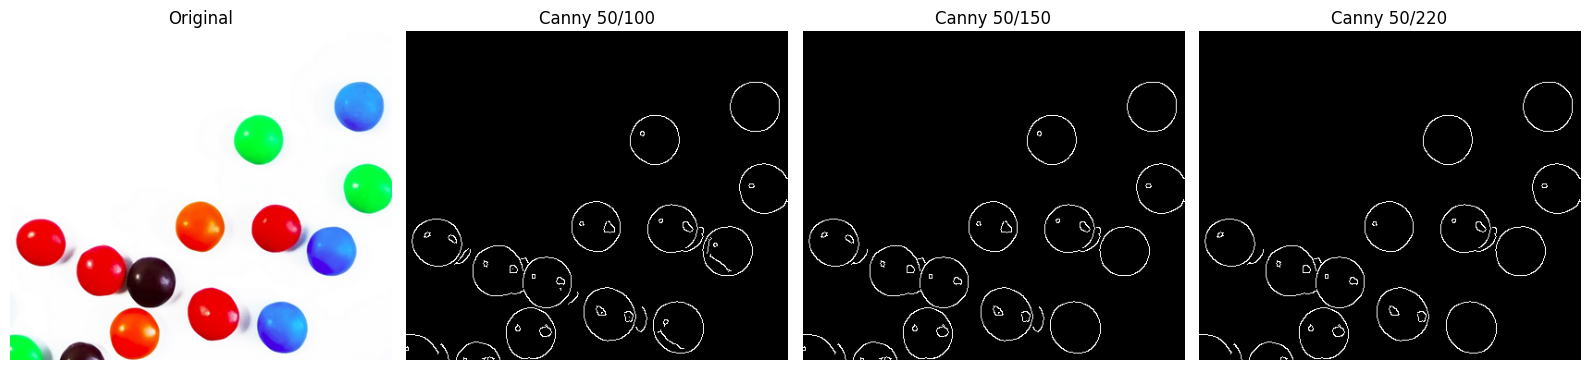

Selected threshold pairs: [(50, 100), (50, 150), (50, 220)]
(50, 100): 3292 edge pixels
(50, 150): 3101 edge pixels
(50, 220): 2940 edge pixels
Inspect which setting retains the desired outlines without too many background or internal edges.


In [19]:
edge_pairs = [(50, 100), (50, 150), (50, 220)]
smooth = cv2.GaussianBlur(cv2.cvtColor(smarties, cv2.COLOR_BGR2GRAY), (5, 5), 0)
edge_results = [cv2.Canny(smooth, low, high) for low, high in edge_pairs]
show_and_save('task05_canny.png', [rgb(smarties), *edge_results],
              ['Original', *[f'Canny {low}/{high}' for low, high in edge_pairs]])
print('Selected threshold pairs:', edge_pairs)
for pair, edge in zip(edge_pairs, edge_results):
    print(f'{pair}: {np.count_nonzero(edge)} edge pixels')
print('Inspect which setting retains the desired outlines without too many background or internal edges.')

## Task 6 — Grow a region in a brain MRI

This is the manual's simple stack-based region growing: compare neighboring pixels with the seed intensity. The two seeds below are **example locations**. Inspect the displayed MRI and edit them to lie inside the two regions you want to compare. Coordinates use `(row, column)`. Three intensity differences are tested for each seed.

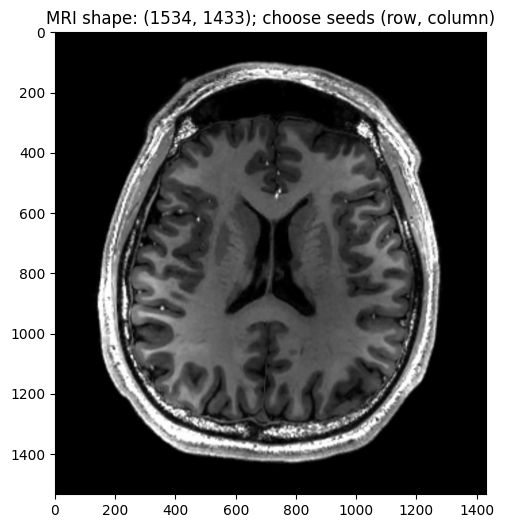

Seed (767, 716), difference 10: 30983 pixels
Seed (767, 716), difference 25: 438535 pixels
Seed (767, 716), difference 50: 803300 pixels
Seed (767, 746), difference 10: 18966 pixels
Seed (767, 746), difference 25: 22438 pixels
Seed (767, 746), difference 50: 56979 pixels


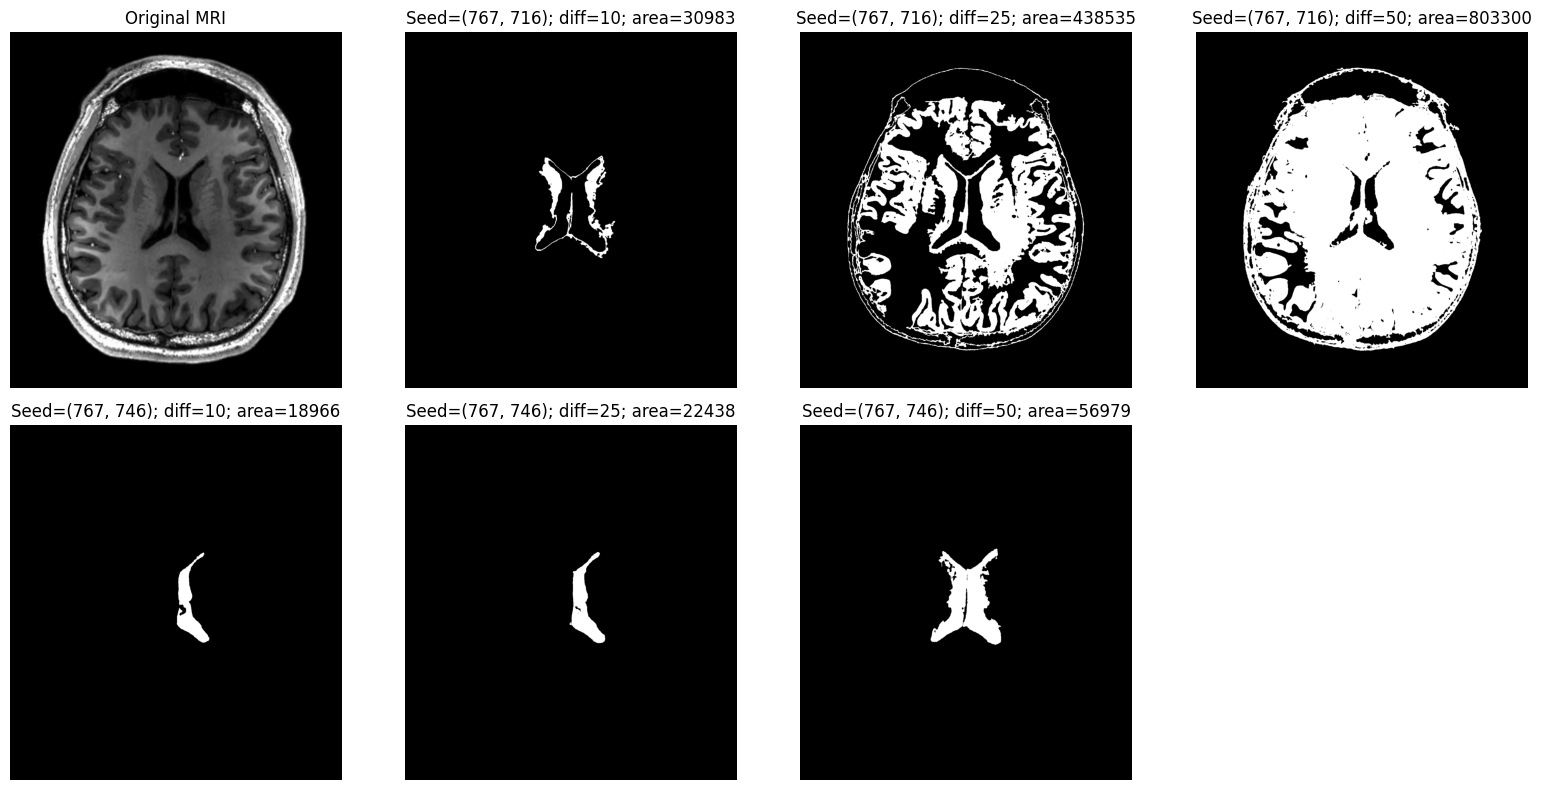

A changed seed can reach a different connected tissue area; a larger threshold usually accepts a wider intensity range.


In [20]:
brain = load_image(BRAIN, gray=True)
plt.figure(figsize=(6, 6)); plt.imshow(brain, cmap='gray'); plt.title(f'MRI shape: {brain.shape}; choose seeds (row, column)'); plt.axis('on'); plt.show()

# Edit these after inspecting the image above.
seeds = [(brain.shape[0] // 2, brain.shape[1] // 2),
         (brain.shape[0] // 2, min(brain.shape[1] - 1, brain.shape[1] // 2 + 30))]
grow_thresholds = [10, 25, 50]

def region_growing(image, seed, threshold):
    height, width = image.shape
    mask = np.zeros((height, width), dtype=np.uint8)
    seen = np.zeros((height, width), dtype=bool)
    stack = [seed]
    seed_value = int(image[seed])
    while stack:
        row, col = stack.pop()
        if not (0 <= row < height and 0 <= col < width) or seen[row, col]:
            continue
        seen[row, col] = True
        if abs(int(image[row, col]) - seed_value) <= threshold:
            mask[row, col] = 255
            stack.extend([(row-1, col), (row+1, col), (row, col-1), (row, col+1)])
    return mask

pictures, labels = [brain], ['Original MRI']
for seed in seeds:
    for difference in grow_thresholds:
        result = region_growing(brain, seed, difference)
        pictures.append(result)
        labels.append(f'Seed={seed}; diff={difference}; area={np.count_nonzero(result)}')
        print(f'Seed {seed}, difference {difference}: {np.count_nonzero(result)} pixels')
show_and_save('task06_region_growing.png', pictures, labels, 4)
print('A changed seed can reach a different connected tissue area; a larger threshold usually accepts a wider intensity range.')

## Task 7 — Separate touching coins with watershed

The stages follow the manual: threshold, open to remove noise, dilate for sure background, distance transform for sure foreground, subtract for unknown pixels, label markers, then watershed. The tutorial coin image has dark coins on a light background, so inverse Otsu thresholding is used. If your downloaded image has light coins on a dark background, change `THRESH_BINARY_INV` to `THRESH_BINARY`.

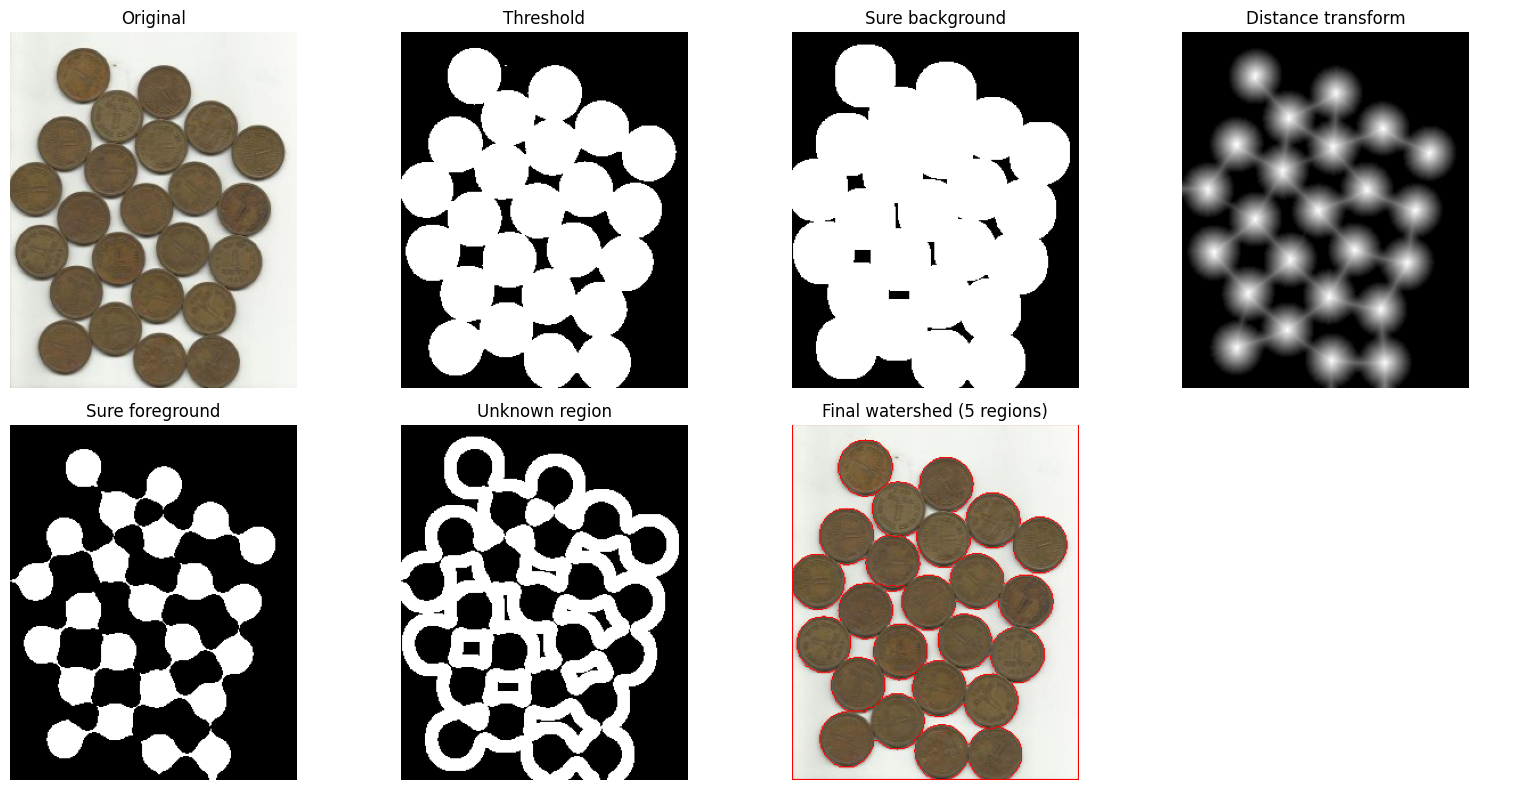

Sure-foreground marker count: 5; final separated regions: 5
Red lines are watershed boundaries. Visually inspect whether the touching coins are split correctly.


In [21]:
def watershed_coins(image, foreground_fraction=0.35):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_background = cv2.dilate(opening, kernel, iterations=3)
    distance = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_foreground = cv2.threshold(distance, foreground_fraction * distance.max(), 255, 0)
    sure_foreground = sure_foreground.astype(np.uint8)
    unknown = cv2.subtract(sure_background, sure_foreground)
    marker_count, markers = cv2.connectedComponents(sure_foreground)
    markers = markers + 1  # Background becomes label 1; unknown will become 0.
    markers[unknown == 255] = 0
    segmented = image.copy()
    final_markers = cv2.watershed(segmented, markers)
    segmented[final_markers == -1] = (0, 0, 255)
    separated_count = len(np.unique(final_markers[final_markers > 1]))
    return binary, sure_background, distance, sure_foreground, unknown, segmented, separated_count, marker_count-1

binary, sure_bg, distance, sure_fg, unknown, watershed_view, regions, markers_found = watershed_coins(coins_color)
show_and_save('task07_watershed.png',
              [rgb(coins_color), binary, sure_bg, distance, sure_fg, unknown, rgb(watershed_view)],
              ['Original', 'Threshold', 'Sure background', 'Distance transform',
               'Sure foreground', 'Unknown region', f'Final watershed ({regions} regions)'], 4)
print(f'Sure-foreground marker count: {markers_found}; final separated regions: {regions}')
print('Red lines are watershed boundaries. Visually inspect whether the touching coins are split correctly.')

## Task 8 — Tune the watershed foreground threshold

Only the distance-transform fraction changes. Record the marker count, final region count and visual quality for four runs. Lower fractions can merge coin centers; higher fractions can remove small coin centers.

Run | Distance threshold | Foreground markers | Separated regions | Observed result
----|--------------------|--------------------|-------------------|----------------
  1 |               0.20 |                  1 |                 1 | first run
  2 |               0.30 |                  2 |                 2 | more regions
  3 |               0.40 |                 27 |                27 | more regions
  4 |               0.50 |                 24 |                24 | fewer regions


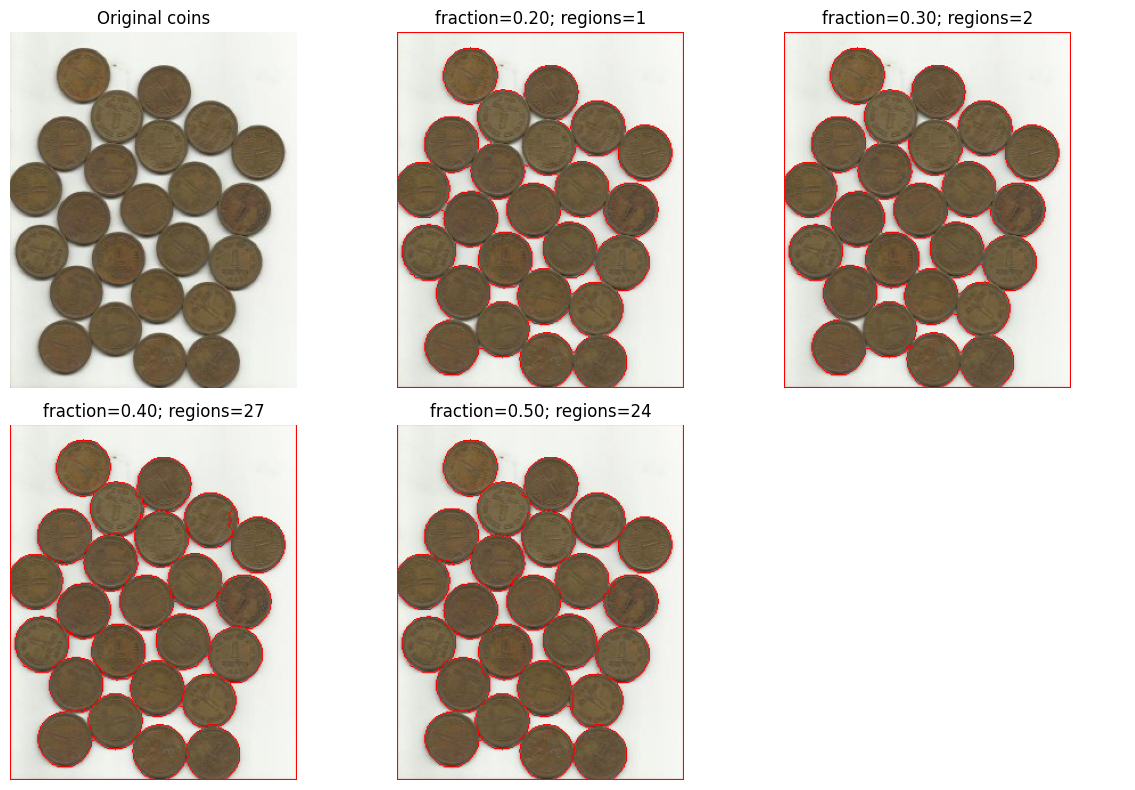

Choose the fraction whose red boundaries best separate actual touching coins without extra splits.


In [22]:
fractions = [0.20, 0.30, 0.40, 0.50]
views, titles = [rgb(coins_color)], ['Original coins']
print('Run | Distance threshold | Foreground markers | Separated regions | Observed result')
print('----|--------------------|--------------------|-------------------|----------------')
previous_count = None
for fraction in fractions:
    _, _, _, _, _, view, count, marker_count = watershed_coins(coins_color, fraction)
    views.append(rgb(view))
    titles.append(f'fraction={fraction:.2f}; regions={count}')
    change = 'first run' if previous_count is None else ('more regions' if count > previous_count else
             'fewer regions' if count < previous_count else 'same region count')
    print(f'{len(views)-1:3d} | {fraction:18.2f} | {marker_count:18d} | {count:17d} | {change}')
    previous_count = count
show_and_save('task08_watershed_tuning.png', views, titles, 3)
print('Choose the fraction whose red boundaries best separate actual touching coins without extra splits.')

## Task 9 — Segment colors with K-Means

As in the manual, reshape BGR pixels to rows, convert to `float32`, cluster them with OpenCV, then rebuild an image from the cluster centers. Compare K = 2, 4 and 6.

K=2: 2 colors; average pixel change=19.5; largest cluster=80.3% of image
K=4: 4 colors; average pixel change=8.0; largest cluster=80.2% of image
K=6: 6 colors; average pixel change=5.3; largest cluster=79.5% of image


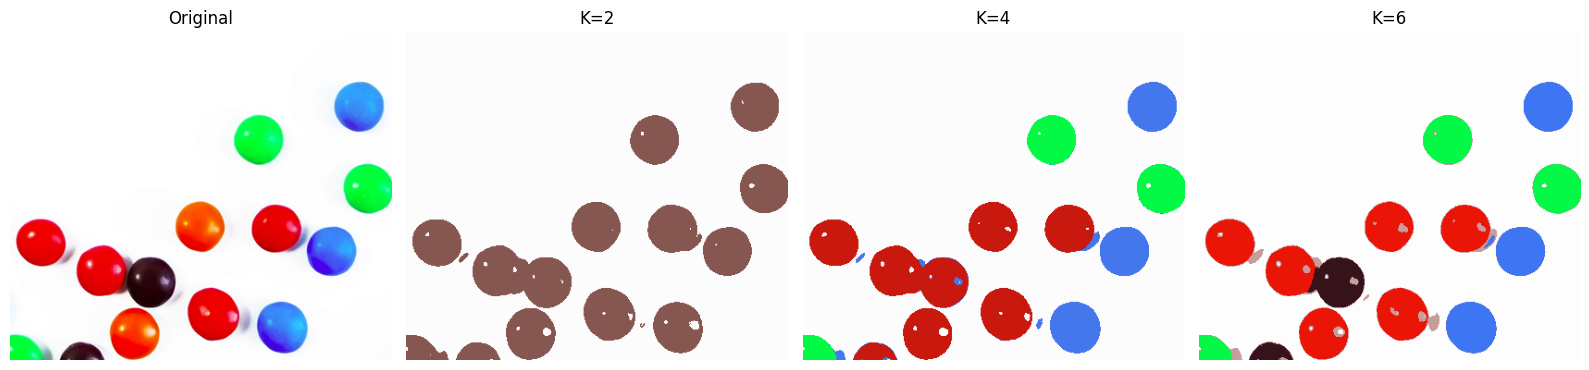

K=2 simplifies colors most; larger K values preserve more separate colors and regions.


In [23]:
cv2.setRNGSeed(5)
pixels = np.float32(smarties.reshape(-1, 3))
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k_values = [2, 4, 6]
kmeans_results = []
for k in k_values:
    compactness, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    result = np.uint8(centers)[labels.flatten()].reshape(smarties.shape)
    kmeans_results.append(rgb(result))
    mean_change = np.mean(np.abs(result.astype(np.float32) - smarties.astype(np.float32)))
    largest_region = np.bincount(labels.flatten(), minlength=k).max() / len(labels) * 100
    print(f'K={k}: {k} colors; average pixel change={mean_change:.1f}; '
          f'largest cluster={largest_region:.1f}% of image')
show_and_save('task09_kmeans.png', [rgb(smarties), *kmeans_results],
              ['Original', *[f'K={k}' for k in k_values]])
print('K=2 simplifies colors most; larger K values preserve more separate colors and regions.')

## Task 10 — Choose a method for an unknown image

Here the challenging image is **Smarties** from Task 4. Compare three allowed approaches on the same picture: HSV color thresholding, grayscale Otsu thresholding and Canny edges. HSV assumes the target objects have a distinct color; Otsu assumes different brightness; Canny looks for intensity changes at boundaries. Each succeeds or fails in a different way.

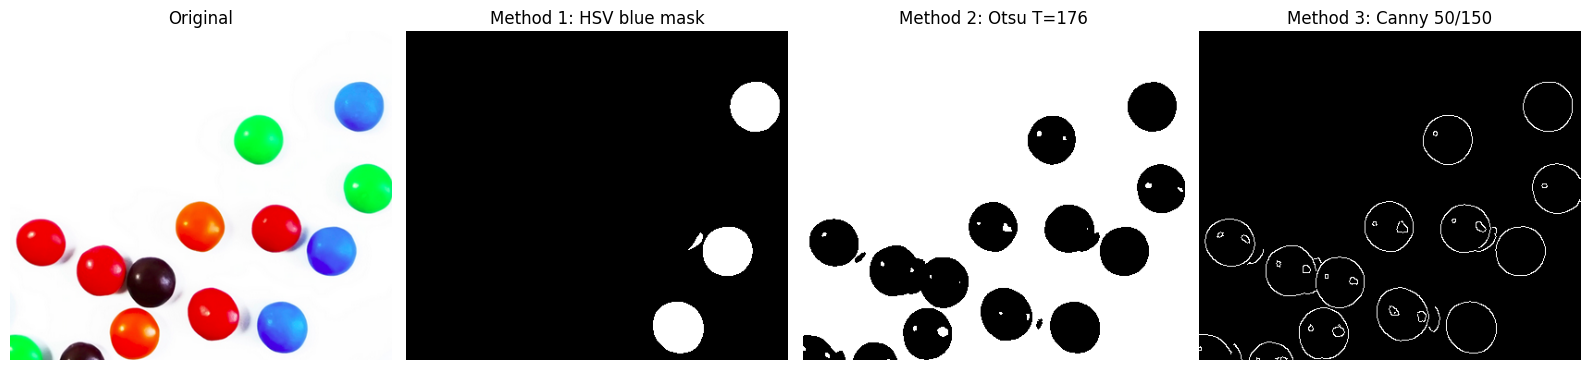

Observed pixel counts:
HSV blue mask: 7139
Otsu white pixels: 118099
Canny edge pixels: 3101
HSV finds blue areas but misses nonblue sweets. Otsu divides bright/dark pixels and can include background. Canny outlines many objects but does not fill them.
For the goal of isolating blue objects in this color image, the HSV mask is the most meaningful of these three outputs. If your image differs, decide from the displayed results.


In [24]:
smarties_gray = cv2.cvtColor(smarties, cv2.COLOR_BGR2GRAY)
task10_t, task10_otsu = cv2.threshold(smarties_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
task10_edges = cv2.Canny(cv2.GaussianBlur(smarties_gray, (5, 5), 0), 50, 150)
show_and_save('task10_three_methods.png',
              [rgb(smarties), color_mask, task10_otsu, task10_edges],
              ['Original', 'Method 1: HSV blue mask', f'Method 2: Otsu T={task10_t:.0f}',
               'Method 3: Canny 50/150'])
print('Observed pixel counts:')
print('HSV blue mask:', np.count_nonzero(color_mask))
print('Otsu white pixels:', np.count_nonzero(task10_otsu))
print('Canny edge pixels:', np.count_nonzero(task10_edges))
print('HSV finds blue areas but misses nonblue sweets. Otsu divides bright/dark pixels and can include background. Canny outlines many objects but does not fill them.')
print('For the goal of isolating blue objects in this color image, the HSV mask is the most meaningful of these three outputs. If your image differs, decide from the displayed results.')